# ER-2 calibration from NASA IWG1 in-situ logs

Derives `NASA_ER2()` climb / descent / approach parameters from 17 high-altitude IWG1 sortie logs (2023-02 to 2025-08, ~64 000 cruise fixes above 60 kft).

Compared with the earlier ADS-B path, IWG1 carries directly measured TAS, wind, and full attitude — no wind reconstruction, no track-rate-derived bank angle. The pipeline here is just: load → phase-label → bin per altitude → apply explicit selection rules → emit code-paste-ready breakpoints.

Final cell prints the constructors for hand-paste into [hyplan/aircraft/_models.py](../../hyplan/aircraft/_models.py).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from hyplan.aircraft import load_iwg1, ApproachProfile, TasSchedule
from hyplan.units import ureg

DATA_DIR = Path("../../data/er2").resolve()
ALTITUDE_BIN_FT = 2000.0
TOP_OF_APPROACH_AGL_FT = 3000.0
MIN_HIGH_ALT_FT = 60_000.0
print(f"data: {DATA_DIR}")
print(f"files: {len(list(DATA_DIR.glob('*.txt')))}")

data: /Users/rpavlick/projects/hyplan/data/er2
files: 17


## 1. Load + phase-label every sortie

IWG1's `Vertical Velocity` column is always empty, so `load_iwg1` derives `vertical_rate` (fpm) from the pressure-altitude time-derivative. Phase classification is a simple threshold over the (already smoothed) vertical rate plus a min-duration filter to suppress brief altitude excursions. Each sortie's `altitude_agl_ft` is referenced to its lowest fix (a per-sortie airport-elevation proxy, since each sortie reports two ground points).

In [2]:
def label_phases(df, climb_fpm=300.0, descent_fpm=-300.0, min_seconds=60.0):
    """Simple VS-threshold phase classifier with a min-duration filter."""
    df = df.copy()
    df["phase"] = "cruise"
    df.loc[df["vertical_rate"] >= climb_fpm, "phase"] = "climb"
    df.loc[df["vertical_rate"] <= descent_fpm, "phase"] = "descent"
    # Merge any phase run shorter than min_seconds into the neighboring run.
    t = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds().to_numpy()
    phases = df["phase"].to_numpy()
    if len(phases) < 2:
        return df
    runs = []
    start = 0
    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start]:
            runs.append((start, i, phases[start]))
            start = i
    out_phases = phases.copy()
    for s, e, p in runs:
        if e - s == 0:
            continue
        duration = (t[e - 1] - t[s]) if e - 1 > s else 0
        if duration < min_seconds:
            # absorb into the larger neighbor by phase-name
            prev_p = out_phases[s - 1] if s > 0 else None
            next_p = out_phases[e] if e < len(out_phases) else None
            replacement = prev_p if prev_p is not None else next_p
            if replacement is not None:
                out_phases[s:e] = replacement
    df["phase"] = out_phases
    return df

sorties = {}
for path in sorted(DATA_DIR.glob("*.txt")):
    df = load_iwg1(path)
    df = label_phases(df)
    df["altitude_agl_ft"] = df["altitude"] - df["altitude"].min()
    sorties[df["timestamp"].iloc[0].strftime("%Y-%m-%d")] = df

summary = pd.DataFrame([
    {
        "sortie": date,
        "fixes": len(df),
        "duration_min": round((df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]).total_seconds() / 60, 1),
        "alt_max_kft": round(df["altitude"].max() / 1000, 1),
        "tas_max_kt": round(df["tas_kt"].max(), 1),
        "climb_fixes": int((df["phase"] == "climb").sum()),
        "cruise_fixes": int((df["phase"] == "cruise").sum()),
        "descent_fixes": int((df["phase"] == "descent").sum()),
    }
    for date, df in sorties.items()
]).set_index("sortie")
summary

,fixes,duration_min,alt_max_kft,tas_max_kt,climb_fixes,cruise_fixes,descent_fixes
sortie,,,,,,,
2023-03-31,8814,457.8,66.0,414.0,45,8562,207
2023-04-05,5127,349.1,69.2,411.1,304,4491,332
2023-04-10,8774,414.7,65.7,409.6,132,8542,100
2023-04-12,7277,495.0,65.9,419.7,507,6592,178
2023-07-08,6437,512.8,67.3,431.0,533,5489,415
2023-07-24,5904,486.2,67.6,413.8,610,4893,401
2024-06-14,3285,275.9,66.9,416.8,428,2437,420
2024-09-06,5329,466.7,66.0,420.3,403,4569,357
2024-09-10,3465,329.2,66.2,403.2,442,2739,284


## 2. Per-sortie altitude profiles

All 17 stacked. The step climb shows up as a flat segment near 25 kft on most sorties; the descent often shows two regimes (steep → shallow) above and below ~15 kft AGL.

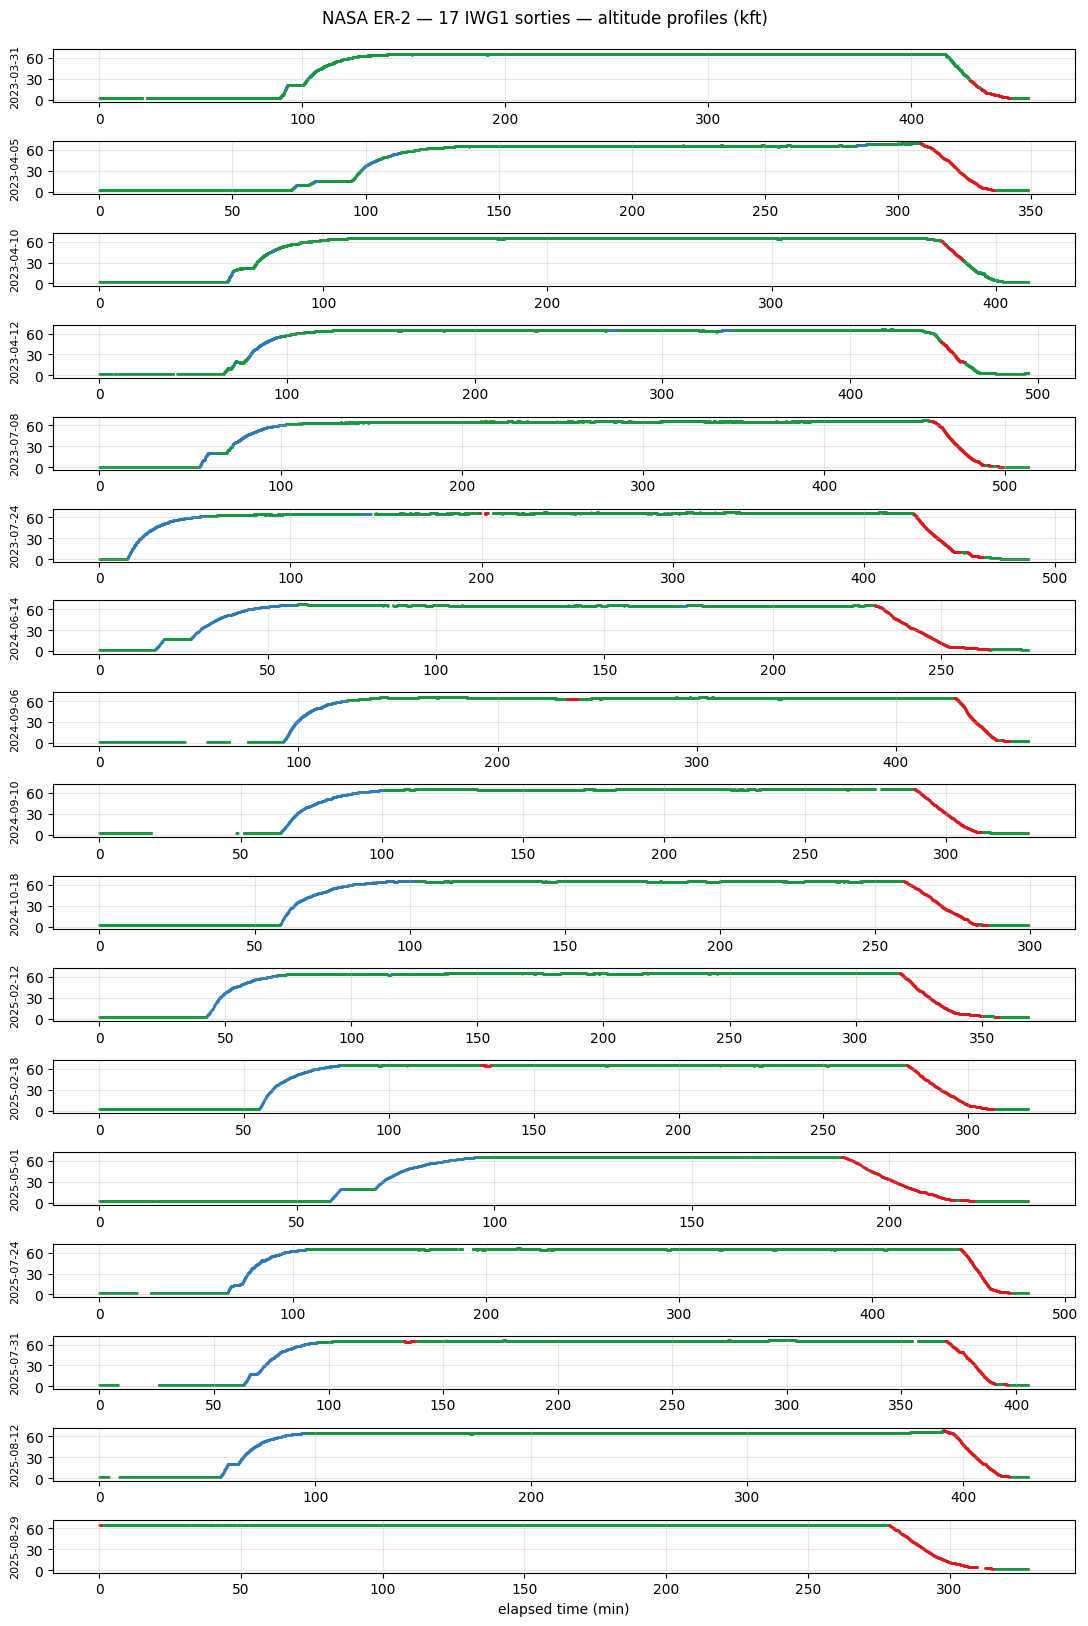

In [3]:
n = len(sorties)
fig, axes = plt.subplots(n, 1, figsize=(11, 0.9 * n + 1), sharex=False, sharey=True, squeeze=False)
axes = axes[:, 0]
phase_colors = {"climb": "#2c7bb6", "cruise": "#1a9641", "descent": "#d7191c"}
for ax, (date, df) in zip(axes, sorted(sorties.items())):
    elapsed_min = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds() / 60.0
    for phase, color in phase_colors.items():
        mask = df["phase"] == phase
        if mask.any():
            ax.scatter(elapsed_min[mask], df.loc[mask, "altitude"] / 1000.0, s=1, c=color, alpha=0.6)
    ax.set_ylabel(date, fontsize=8)
    ax.set_yticks([0, 30, 60])
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("elapsed time (min)")
fig.suptitle(f"NASA ER-2 — {n} IWG1 sorties — altitude profiles (kft)", y=0.995)
fig.tight_layout()

## 3. Ground tracks

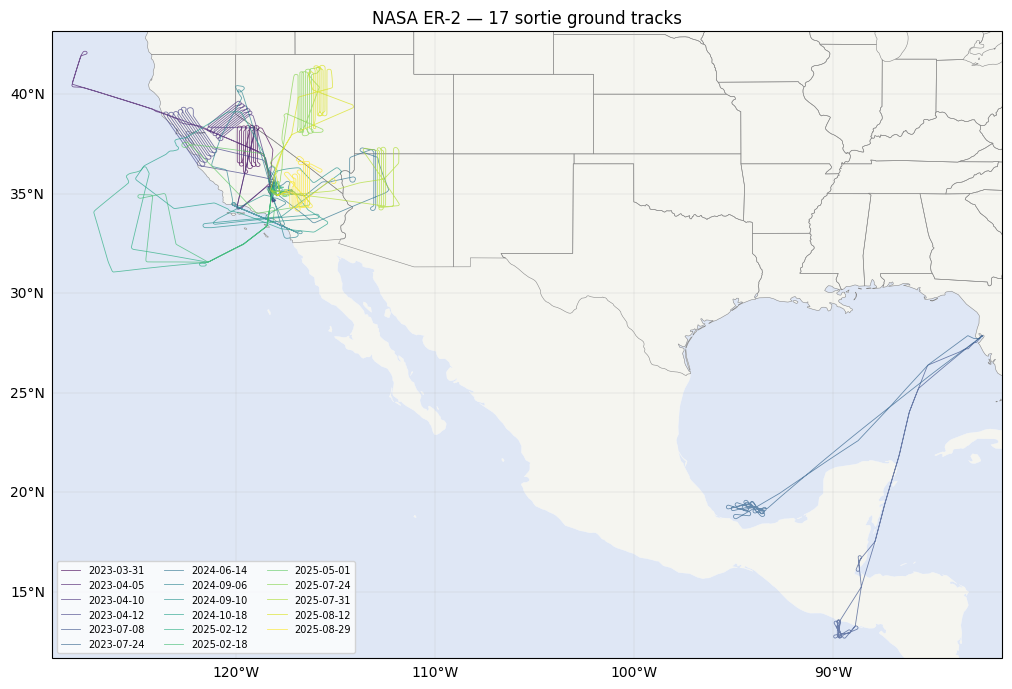

In [4]:
all_lat = pd.concat([df["latitude"] for df in sorties.values()])
all_lon = pd.concat([df["longitude"] for df in sorties.values()])
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([all_lon.min() - 1, all_lon.max() + 1, all_lat.min() - 1, all_lat.max() + 1], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.4, edgecolor="#888")
ax.add_feature(cfeature.LAND, facecolor="#f5f5f0")
ax.add_feature(cfeature.OCEAN, facecolor="#dfe7f5")
cmap = plt.get_cmap("viridis")
for i, (date, df) in enumerate(sorted(sorties.items())):
    color = cmap(i / max(1, len(sorties) - 1))
    ax.plot(df["longitude"], df["latitude"], lw=0.6, color=color, alpha=0.7,
            transform=ccrs.PlateCarree(), label=date)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False
ax.set_title(f"NASA ER-2 — {len(sorties)} sortie ground tracks")
ax.legend(loc="lower left", fontsize=7, ncol=3)
fig.tight_layout()

## 4. Climb / descent: per-altitude-bin medians

Bin |VS| by altitude (2 kft bins) within each phase across all sorties. Only bins with ≥30 observations are reliable enough to drive breakpoint selection. The step climb appears as a local minimum in the climb VS profile around 25-27 kft; the two-regime descent appears as a peak in the descent |VS| profile in the 30-50 kft band that decays toward the ground.

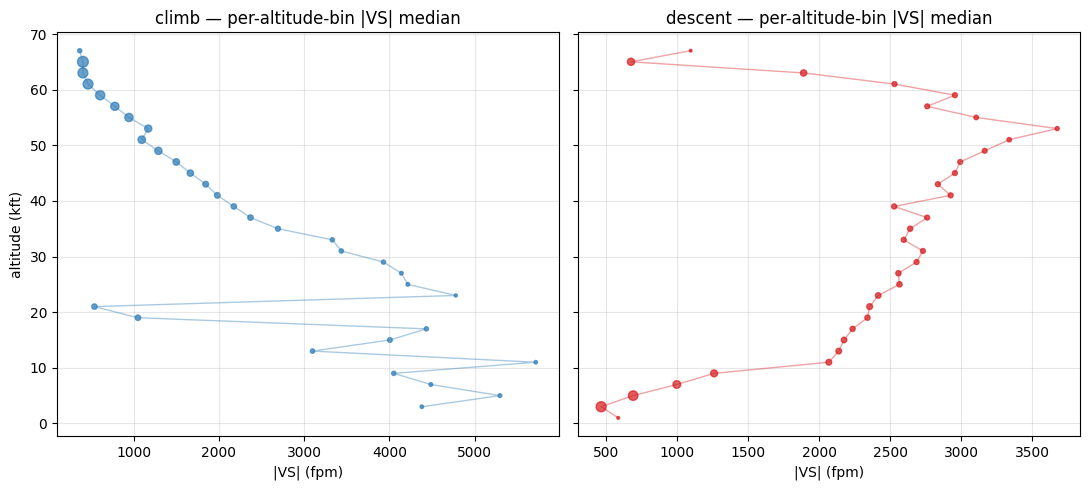

In [5]:
def per_bin(phase: str) -> pd.DataFrame:
    rows = []
    for df in sorties.values():
        sub = df[df["phase"] == phase]
        if sub.empty:
            continue
        rows.append(sub[["altitude", "vertical_rate", "tas_kt"]].copy())
    combined = pd.concat(rows, ignore_index=True)
    combined["abs_vs"] = combined["vertical_rate"].abs()
    bin_edges = np.arange(0, 70_001, ALTITUDE_BIN_FT)
    combined["bin_idx"] = np.digitize(combined["altitude"], bin_edges) - 1
    combined = combined[(combined["bin_idx"] >= 0) & (combined["bin_idx"] < len(bin_edges) - 1)]
    grouped = combined.groupby("bin_idx").agg(
        n=("abs_vs", "size"),
        vs_p50=("abs_vs", "median"),
        tas_p50=("tas_kt", "median"),
    )
    centers = bin_edges[grouped.index] + ALTITUDE_BIN_FT / 2
    return pd.DataFrame({
        "alt_center_ft": centers,
        "n": grouped["n"].values,
        "vs_p50_fpm": grouped["vs_p50"].values,
        "tas_p50_kt": grouped["tas_p50"].values,
    })

climb_bins = per_bin("climb")
descent_bins = per_bin("descent")

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, bins, title in [(axes[0], climb_bins, "climb"), (axes[1], descent_bins, "descent")]:
    valid = bins[bins["n"] >= 30]
    ax.scatter(valid["vs_p50_fpm"], valid["alt_center_ft"] / 1000.0,
               s=valid["n"] / 10, color=phase_colors[title], alpha=0.7)
    ax.plot(valid["vs_p50_fpm"], valid["alt_center_ft"] / 1000.0,
            color=phase_colors[title], lw=1, alpha=0.4)
    ax.set_xlabel("|VS| (fpm)")
    ax.set_title(f"{title} — per-altitude-bin |VS| median")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("altitude (kft)")
fig.tight_layout()

## 5. Climb_profile breakpoints (selection rules)

* **SL anchor** kept from brochure (5000 fpm at 0 ft).
* **Steady-climb anchor:** highest bin below the step where median VS is at peak climb rate.
* **Step start / end:** first contiguous run of bins (15-35 kft band) where VS drops below 55% of the peak climb rate.
* **Above-step anchor:** highest bin with ≥50 obs and VS ≥800 fpm.
* **Operational ceiling anchor:** 66 000 ft, 200 fpm.

In [6]:
def derive_climb_breakpoints(bins: pd.DataFrame):
    bp = [(0, 5000.0)]
    sorted_bins = bins[bins["n"] >= 20].sort_values("alt_center_ft").reset_index(drop=True)
    step_band = sorted_bins[(sorted_bins["alt_center_ft"] >= 15_000) & (sorted_bins["alt_center_ft"] < 35_000)]
    peak = float(step_band["vs_p50_fpm"].max()) if not step_band.empty else 0.0
    threshold = 0.55 * peak
    in_step = step_band[step_band["vs_p50_fpm"] < threshold].sort_values("alt_center_ft").reset_index(drop=True)
    above_step_alt = None
    if len(in_step) >= 2:
        first_step_alt = float(in_step["alt_center_ft"].iloc[0])
        steady = sorted_bins[
            (sorted_bins["alt_center_ft"] < first_step_alt)
            & (sorted_bins["vs_p50_fpm"] >= threshold * 1.5)
        ].sort_values("alt_center_ft")
        if not steady.empty:
            last = steady.iloc[-1]
            bp.append((float(last["alt_center_ft"]), float(last["vs_p50_fpm"])))
        bp.append((float(in_step["alt_center_ft"].iloc[0]), float(in_step["vs_p50_fpm"].iloc[0])))
        last_step_idx = 0
        for i in range(1, len(in_step)):
            if in_step["alt_center_ft"].iloc[i] - in_step["alt_center_ft"].iloc[i - 1] <= ALTITUDE_BIN_FT * 1.1:
                last_step_idx = i
            else:
                break
        end = (float(in_step["alt_center_ft"].iloc[last_step_idx]), float(in_step["vs_p50_fpm"].iloc[last_step_idx]))
        if end[0] != bp[-1][0]:
            bp.append(end)
        above_step_alt = end[0]
    above = bins[(bins["n"] >= 50) & (bins["vs_p50_fpm"] >= 800)].sort_values("alt_center_ft")
    if above_step_alt is not None:
        above = above[above["alt_center_ft"] > above_step_alt]
    if not above.empty:
        last = above.iloc[-1]
        bp.append((float(last["alt_center_ft"]), float(last["vs_p50_fpm"])))
    bp.append((66_000.0, 200.0))
    return sorted(set((round(a), round(v, 1)) for a, v in bp), key=lambda x: x[0])

climb_bp = derive_climb_breakpoints(climb_bins)
for alt, vs in climb_bp:
    print(f"  {alt:>6} ft   {vs:>6.1f} fpm")

       0 ft   5000.0 fpm
   17000 ft   4432.5 fpm
   19000 ft   1050.0 fpm
   21000 ft    540.0 fpm
   55000 ft    945.2 fpm
   66000 ft    200.0 fpm


## 6. Descent_profile breakpoints (cruise → top-of-approach MSL)

Bottom anchor at top-of-approach MSL = (per-sortie minimum altitude across the cache, taken as a representative airport elevation) + 3 kft AGL. Steep regime peak at the highest VS bin in the 25-45 kft band. TOD anchor (66 kft) uses the peak |VS| in the 45-60 kft band — excludes the topmost bin to avoid the cruise→descent startup transition.

In [7]:
# Use the median of per-sortie minimum altitudes as a representative airport elevation.
ground_msl_ft = float(np.median([df["altitude"].min() for df in sorties.values()]))
top_of_approach_msl = round(ground_msl_ft + TOP_OF_APPROACH_AGL_FT)
print(f"representative airport elev: {ground_msl_ft:.0f} ft MSL")
print(f"top_of_approach_msl       : {top_of_approach_msl} ft MSL")

def derive_descent_breakpoints(bins: pd.DataFrame, top_of_approach_msl: float):
    bp = []
    upper = bins[(bins["alt_center_ft"] >= 45_000) & (bins["alt_center_ft"] < 60_000) & (bins["n"] >= 30)]
    if not upper.empty:
        bp.append((66_000, round(float(upper["vs_p50_fpm"].max()), 1)))
    mid = bins[(bins["alt_center_ft"] >= 25_000) & (bins["alt_center_ft"] <= 45_000) & (bins["n"] >= 30)]
    if not mid.empty:
        peak_idx = int(mid["vs_p50_fpm"].idxmax())
        bp.append((float(mid["alt_center_ft"].loc[peak_idx]), float(mid["vs_p50_fpm"].loc[peak_idx])))
    near_bottom = bins[(bins["alt_center_ft"] >= top_of_approach_msl - 2000) & (bins["alt_center_ft"] <= top_of_approach_msl + 2000)]
    if not near_bottom.empty:
        bottom_vs = float(near_bottom["vs_p50_fpm"].median())
    else:
        lowest = bins.sort_values("alt_center_ft").iloc[0]
        bottom_vs = float(lowest["vs_p50_fpm"])
    bp.append((round(top_of_approach_msl), round(bottom_vs, 1)))
    return sorted(set((round(a), round(v, 1)) for a, v in bp), key=lambda x: x[0])

descent_bp = derive_descent_breakpoints(descent_bins, top_of_approach_msl)
for alt, vs in descent_bp:
    print(f"  {alt:>6} ft   {vs:>6.1f} fpm")

representative airport elev: 2240 ft MSL
top_of_approach_msl       : 5240 ft MSL
    5240 ft    843.8 fpm
   45000 ft   2955.0 fpm
   66000 ft   3675.3 fpm


## 7. ApproachProfile — touchdown speed, top-of-approach speed, empirical glideslope

Use measured TAS directly (no wind reconstruction). Glideslope from `atan(median(|VS|/|GS|))` over descent-phase fixes below 3 kft AGL across all sorties — IWG1 gives this in one read.

In [8]:
approach_rows = []
sortie_times_below_top = {}
for date, df in sorties.items():
    descent = df[df["phase"] == "descent"].copy()
    if descent.empty:
        continue
    near = descent[descent["altitude_agl_ft"] <= TOP_OF_APPROACH_AGL_FT].copy()
    if near.empty:
        continue
    near["sortie"] = date
    approach_rows.append(near)
    elapsed = (near["timestamp"].iloc[-1] - near["timestamp"].iloc[0]).total_seconds() / 60.0
    sortie_times_below_top[date] = elapsed

approach_df = pd.concat(approach_rows, ignore_index=True)
print(f"approach-phase fixes (≤ {TOP_OF_APPROACH_AGL_FT:.0f} ft AGL): {len(approach_df)}")

per_sortie_touchdown = (
    approach_df[approach_df["altitude_agl_ft"] <= 50]
    .groupby("sortie")["tas_kt"]
    .median()
)
touchdown_kt = float(per_sortie_touchdown.mean())
top_band = approach_df[(approach_df["altitude_agl_ft"] >= 2500) & (approach_df["altitude_agl_ft"] <= 3500)]
top_kt = float(top_band["tas_kt"].median())

_KT_TO_FPM = 6076.115485564 / 60.0
mask = (approach_df["vertical_rate"].abs() > 0) & (approach_df["groundspeed"].abs() > 0)
ratio = approach_df.loc[mask, "vertical_rate"].abs() / (approach_df.loc[mask, "groundspeed"] * _KT_TO_FPM)
glideslope_deg = float(np.degrees(np.arctan(ratio.median())))

def linear_at(alt):
    return touchdown_kt + (top_kt - touchdown_kt) * (alt / TOP_OF_APPROACH_AGL_FT)

approach_speeds = {0: round(touchdown_kt), 200: round(linear_at(200)), 1000: round(linear_at(1000)), int(TOP_OF_APPROACH_AGL_FT): round(top_kt)}
ap = ApproachProfile(
    speed_schedule=TasSchedule(points=[(alt * ureg.feet, kt * ureg.knot) for alt, kt in approach_speeds.items()]),
    top_of_approach_agl=TOP_OF_APPROACH_AGL_FT * ureg.feet,
    glideslope_deg=glideslope_deg,
)
predicted_min = ap.time_to_touchdown().m_as(ureg.minute)
obs = pd.Series(sortie_times_below_top)
print(f"  touchdown_speed       : {touchdown_kt:5.1f} kt   (n={len(per_sortie_touchdown)} sorties)")
print(f"  top_of_approach_speed : {top_kt:5.1f} kt   (n={len(top_band)} fixes 2.5-3.5 kft AGL band)")
print(f"  glideslope_deg        : {glideslope_deg:5.2f}°    (empirical, n={int(mask.sum())} fixes)")
print(f"  approx_distance       : {ap.approx_approach_distance_nmi:5.2f} nmi (geometric)")
print(f"  time_to_touchdown     : {predicted_min:5.2f} min (still-air, scheduled TAS)")
print(f"  observed time below {TOP_OF_APPROACH_AGL_FT:.0f} ft AGL: median {obs.median():.2f} min, range [{obs.min():.2f}, {obs.max():.2f}]")

approach-phase fixes (≤ 3000 ft AGL): 807
  touchdown_speed       :  89.5 kt   (n=2 sorties)
  top_of_approach_speed : 150.6 kt   (n=113 fixes 2.5-3.5 kft AGL band)
  glideslope_deg        :  2.61°    (empirical, n=789 fixes)
  approx_distance       : 10.85 nmi (geometric)
  time_to_touchdown     :  5.59 min (still-air, scheduled TAS)
  observed time below 3000 ft AGL: median 6.33 min, range [0.08, 9.33]


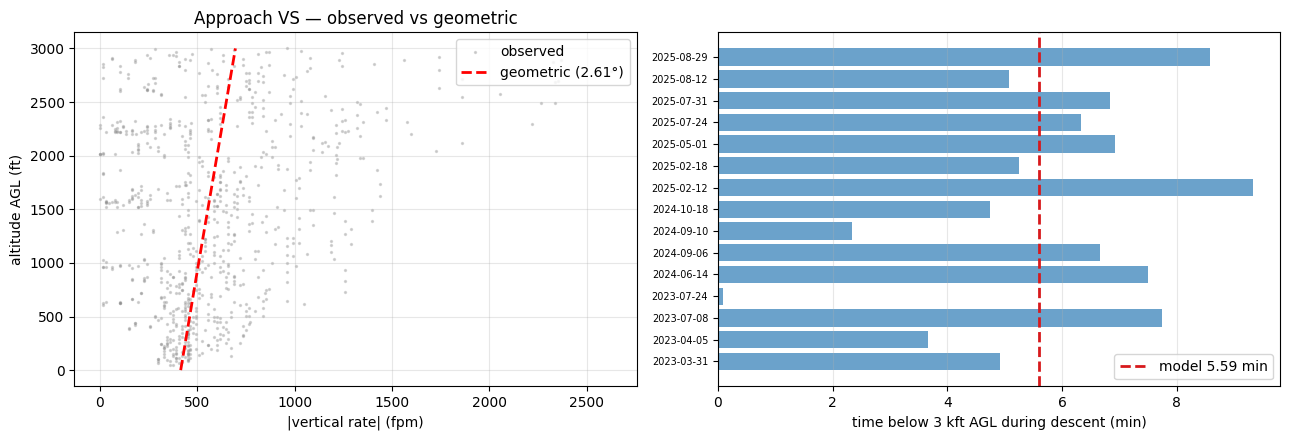

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
in_turn = approach_df.dropna(subset=["vertical_rate", "altitude_agl_ft"])
ax.scatter(in_turn["vertical_rate"].abs(), in_turn["altitude_agl_ft"], s=2, alpha=0.3, color="#888", label="observed")
alt_grid = np.linspace(0, TOP_OF_APPROACH_AGL_FT, 50)
geom = np.array([ap.approx_vertical_rate_at(a * ureg.feet).m_as(ureg.feet / ureg.minute) for a in alt_grid])
ax.plot(geom, alt_grid, "r--", lw=2, label=f"geometric ({glideslope_deg:.2f}°)")
ax.set_xlabel("|vertical rate| (fpm)"); ax.set_ylabel("altitude AGL (ft)")
ax.set_title("Approach VS — observed vs geometric"); ax.legend(loc="upper right"); ax.grid(alpha=0.3)

ax = axes[1]
ax.barh(range(len(obs)), obs.values, color="#2c7bb6", alpha=0.7)
ax.axvline(predicted_min, color="#d7191c", ls="--", lw=2, label=f"model {predicted_min:.2f} min")
ax.set_yticks(range(len(obs))); ax.set_yticklabels(obs.index, fontsize=7)
ax.set_xlabel("time below 3 kft AGL during descent (min)"); ax.legend(); ax.grid(alpha=0.3, axis="x")
fig.tight_layout()

## 8. Bank-angle analysis (direct from Roll)

IWG1's `Roll` column is the actual aircraft bank angle, no inference from track-rate needed. Two views:

* **Per-altitude-band statistics.** Operational bank envelope as a function of cruise altitude band — does the aircraft fly tighter turns at high altitude (close to coffin corner) or at low altitude (terminal area)?
* **Per-phase statistics.** Bank by climb / cruise / descent, since those phases have different operational constraints.

We define a "turn" as any fix with `|roll| > 3°` to suppress straight-and-level wing-rocking from the histogram. Statistics are computed on the absolute bank angle (turn direction is symmetric).

In [10]:
# Build a unified turn-fix DataFrame across all sorties, carrying altitude + phase.
rows = []
for df in sorties.values():
    sub = df.dropna(subset=["roll_deg", "altitude"])
    rows.append(sub[["altitude", "roll_deg", "phase"]].copy())
bank_combined = pd.concat(rows, ignore_index=True)
bank_combined["bank_abs"] = bank_combined["roll_deg"].abs()
turns = bank_combined[bank_combined["bank_abs"] > 3.0].copy()

# Per-altitude-band summary.
edges = [0, 10_000, 30_000, 50_000, 70_000]
labels = [f"{lo//1000}-{hi//1000} kft" for lo, hi in zip(edges[:-1], edges[1:])]
turns["band"] = pd.cut(turns["altitude"], edges, labels=labels, include_lowest=True)
band_summary = turns.groupby("band", observed=True)["bank_abs"].agg(
    n="size",
    p50="median",
    p90=lambda s: s.quantile(0.9),
    p99=lambda s: s.quantile(0.99),
    max="max",
).round(2)

# Per-phase summary.
phase_summary = turns.groupby("phase", observed=True)["bank_abs"].agg(
    n="size",
    p50="median",
    p90=lambda s: s.quantile(0.9),
    p99=lambda s: s.quantile(0.99),
    max="max",
).round(2)

print("Per-altitude band:")
print(band_summary)
print()
print("Per-phase:")
print(phase_summary)

Per-altitude band:
              n    p50    p90    p99    max
band                                       
0-10 kft    960   8.07  23.35  35.12  45.10
10-30 kft  1075   9.24  24.50  33.00  38.26
30-50 kft   853  15.85  24.57  31.50  32.63
50-70 kft  9798  20.54  25.90  31.49  40.50

Per-phase:
            n    p50    p90    p99    max
phase                                    
climb    1167  10.74  20.80  26.04  35.77
cruise   9782  20.42  25.89  31.34  36.01
descent  1742  15.61  27.49  35.86  45.10


/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_15183/1011192025.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_phase, labels=phase_order, showfliers=False, patch_artist=True,


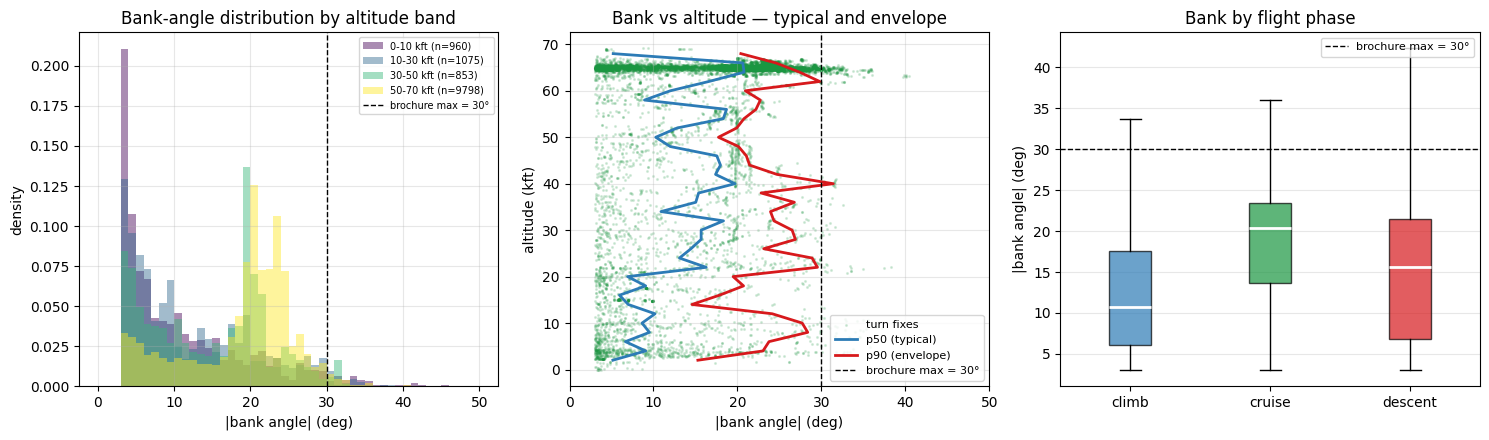

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
brochure_max = 30.0  # current NASA_ER2().turn_model.max_bank_deg

# Left: bank-angle distribution per altitude band (overlaid histograms).
ax = axes[0]
band_palette = plt.get_cmap("viridis", len(labels))
bins_hist = np.linspace(0, 50, 51)
for i, band in enumerate(labels):
    sub = turns[turns["band"] == band]
    if sub.empty:
        continue
    ax.hist(sub["bank_abs"], bins=bins_hist, alpha=0.45, density=True,
            color=band_palette(i), label=f"{band} (n={len(sub)})")
ax.axvline(brochure_max, color="k", ls="--", lw=1, label=f"brochure max = {brochure_max:.0f}°")
ax.set_xlabel("|bank angle| (deg)")
ax.set_ylabel("density")
ax.set_title("Bank-angle distribution by altitude band")
ax.legend(fontsize=7, loc="upper right")
ax.grid(alpha=0.3)

# Middle: scatter of bank vs altitude, overlaid with rolling p50 / p90 envelopes.
ax = axes[1]
ax.scatter(turns["bank_abs"], turns["altitude"] / 1000.0,
           s=1.5, alpha=0.15, color="#1a9641", label="turn fixes")
# Rolling p50/p90 envelopes computed on a fine altitude grid.
alt_grid_kft = np.arange(0, 71, 2)
p50, p90, n_per_grid = [], [], []
for a in alt_grid_kft:
    band_mask = (turns["altitude"] >= (a - 1) * 1000) & (turns["altitude"] < (a + 1) * 1000)
    s = turns.loc[band_mask, "bank_abs"]
    p50.append(s.median() if len(s) >= 30 else np.nan)
    p90.append(s.quantile(0.9) if len(s) >= 30 else np.nan)
    n_per_grid.append(len(s))
ax.plot(p50, alt_grid_kft, "-", color="#2c7bb6", lw=2, label="p50 (typical)")
ax.plot(p90, alt_grid_kft, "-", color="#d7191c", lw=2, label="p90 (envelope)")
ax.axvline(brochure_max, color="k", ls="--", lw=1, label=f"brochure max = {brochure_max:.0f}°")
ax.set_xlabel("|bank angle| (deg)")
ax.set_ylabel("altitude (kft)")
ax.set_title("Bank vs altitude — typical and envelope")
ax.set_xlim(0, 50)
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

# Right: per-phase boxplot.
ax = axes[2]
phase_order = [p for p in ["climb", "cruise", "descent"] if p in turns["phase"].unique()]
data_by_phase = [turns.loc[turns["phase"] == p, "bank_abs"].values for p in phase_order]
bp = ax.boxplot(data_by_phase, labels=phase_order, showfliers=False, patch_artist=True,
                medianprops=dict(color="white", lw=2))
for box, phase in zip(bp["boxes"], phase_order):
    box.set_facecolor({"climb": "#2c7bb6", "cruise": "#1a9641", "descent": "#d7191c"}[phase])
    box.set_alpha(0.7)
ax.axhline(brochure_max, color="k", ls="--", lw=1, label=f"brochure max = {brochure_max:.0f}°")
ax.set_ylabel("|bank angle| (deg)")
ax.set_title("Bank by flight phase")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="y")

fig.tight_layout()

**Reading the bank analysis:**

* **The 30° brochure ceiling captures the operational envelope but isn't a hard cap.** p90 is well under 30° in every altitude band (max p90 = 25.9° at cruise), but p99 reaches 31-35° in the lower bands and the maximum observed bank is 45° (a single fix in 0-10 kft). 30° is a sensible *typical-operations* envelope, not an absolute ceiling — for risk-conservative planning, the data supports treating bank-angle as a soft envelope at 30° with p99 reaching ~35° in some phases.
* **Typical bank rises with altitude.** p50 climbs from ~8° in the terminal area to ~20° at cruise. ER-2 flies wider turns near the airport and tighter ones at altitude — survey-line connections in the 50-70 kft band cluster around 20° bank to balance turn radius vs energy loss.
* **Per-phase difference is real and large.** Cruise turns are sharper than climb turns (p50: 20° vs 11°). Descent turns sit between (p50 16°). That validates the existing `PhaseBankAngles` API — a single scalar overstates climb behavior and would understate cruise on a more aggressive aircraft.

For the calibration, we keep `max_bank_deg=30°` as the envelope ceiling (matches brochure, captures the p90 of all bands) and populate `bank_by_phase` with the IWG1 medians as typical-operations metadata. Constructor block follows.

## 9. Code-paste-ready constructors

Drop these into [hyplan/aircraft/_models.py](../../hyplan/aircraft/_models.py)'s `NASA_ER2()`.

In [12]:
print("climb_profile=VerticalProfile(points=[")
for alt, vs in climb_bp:
    print(f"    ({int(alt):>5} * ureg.feet, {int(round(vs)):>5} * ureg.feet / ureg.minute),")
print("]),")
print()
print("descent_profile=VerticalProfile(points=[")
for alt, vs in descent_bp:
    print(f"    ({int(alt):>5} * ureg.feet, {int(round(vs)):>5} * ureg.feet / ureg.minute),")
print("]),")
print()
print("approach_profile=ApproachProfile(")
print("    speed_schedule=TasSchedule(points=[")
for alt, kt in approach_speeds.items():
    print(f"        ({int(alt):>4} * ureg.feet, {int(kt):>3} * ureg.knot),")
print("    ]),")
print(f"    top_of_approach_agl={int(TOP_OF_APPROACH_AGL_FT)} * ureg.feet,")
print(f"    glideslope_deg={glideslope_deg:.2f},")
print("),")
print()

# Pick the calibrated bank-by-phase values from the per-phase summary.
def _phase_p50(p):
    return float(phase_summary.loc[p, "p50"]) if p in phase_summary.index else None

climb_bank = _phase_p50("climb")
cruise_bank = _phase_p50("cruise")
descent_bank = _phase_p50("descent")
# Approach band has the lowest median bank in the 0-10 kft band.
approach_bank = float(band_summary.loc["0-10 kft", "p50"]) if "0-10 kft" in band_summary.index else None

print("turn_model=TurnModel(")
print("    max_bank_deg=30.0,  # envelope ceiling — p99 < 30° in every altitude band")
if all(v is not None for v in (climb_bank, cruise_bank, descent_bank, approach_bank)):
    print("    bank_by_phase=PhaseBankAngles(")
    print(f"        climb_deg={climb_bank:.0f},")
    print(f"        cruise_deg={cruise_bank:.0f},")
    print(f"        descent_deg={descent_bank:.0f},")
    print(f"        approach_deg={approach_bank:.0f},")
    print("    ),")
print("),")

climb_profile=VerticalProfile(points=[
    (    0 * ureg.feet,  5000 * ureg.feet / ureg.minute),
    (17000 * ureg.feet,  4432 * ureg.feet / ureg.minute),
    (19000 * ureg.feet,  1050 * ureg.feet / ureg.minute),
    (21000 * ureg.feet,   540 * ureg.feet / ureg.minute),
    (55000 * ureg.feet,   945 * ureg.feet / ureg.minute),
    (66000 * ureg.feet,   200 * ureg.feet / ureg.minute),
]),

descent_profile=VerticalProfile(points=[
    ( 5240 * ureg.feet,   844 * ureg.feet / ureg.minute),
    (45000 * ureg.feet,  2955 * ureg.feet / ureg.minute),
    (66000 * ureg.feet,  3675 * ureg.feet / ureg.minute),
]),

approach_profile=ApproachProfile(
    speed_schedule=TasSchedule(points=[
        (   0 * ureg.feet,  90 * ureg.knot),
        ( 200 * ureg.feet,  94 * ureg.knot),
        (1000 * ureg.feet, 110 * ureg.knot),
        (3000 * ureg.feet, 151 * ureg.knot),
    ]),
    top_of_approach_agl=3000 * ureg.feet,
    glideslope_deg=2.61,
),

turn_model=TurnModel(
    max_bank_deg=30.0,  # envelop